# 01 - Data Exploration

Food Delivery Time Prediction - first look at the raw data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/raw/food_delivery.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB


Checking for missing values.

In [5]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


Target variable: `Delivery_Time_min`. Let's see how it's distributed.

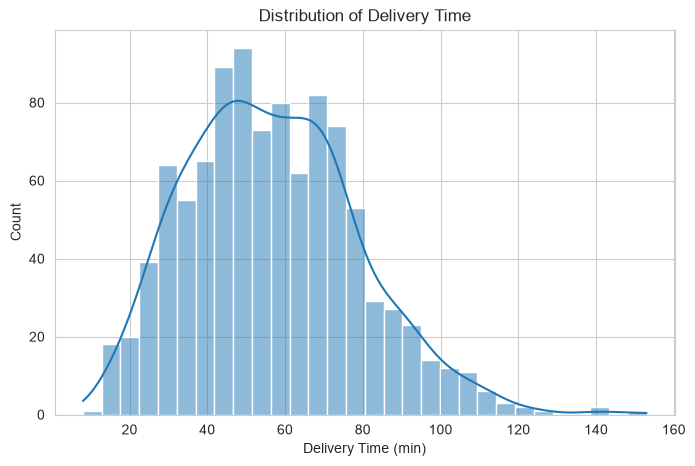

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_min'], bins=30, kde=True)
plt.xlabel('Delivery Time (min)')
plt.title('Distribution of Delivery Time')
plt.show()

Distance is probably the strongest predictor, let's check.

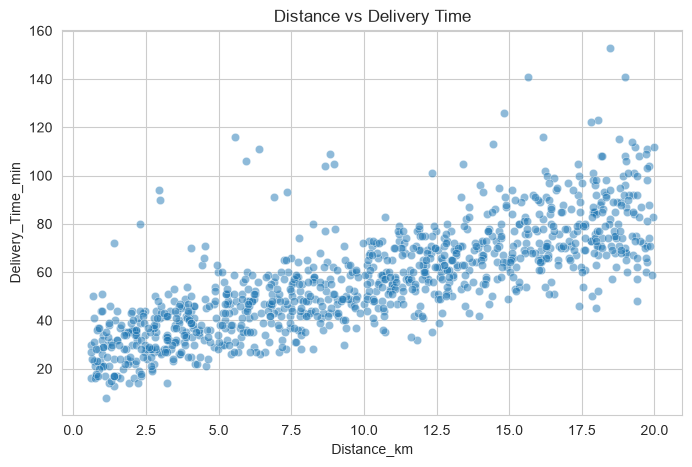

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min', alpha=0.5)
plt.title('Distance vs Delivery Time')
plt.show()

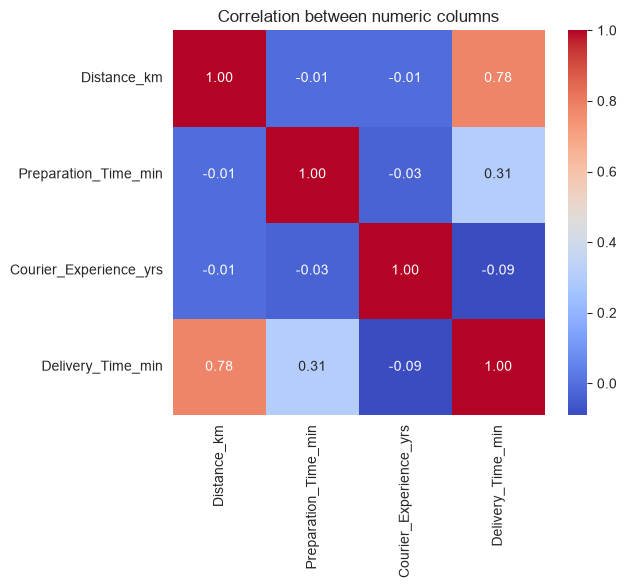

In [9]:
num_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between numeric columns')
plt.show()

Now the categorical columns - weather, traffic, time of day, vehicle type.

In [9]:
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Weather
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic_Level
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time_of_Day
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Vehicle_Type
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64



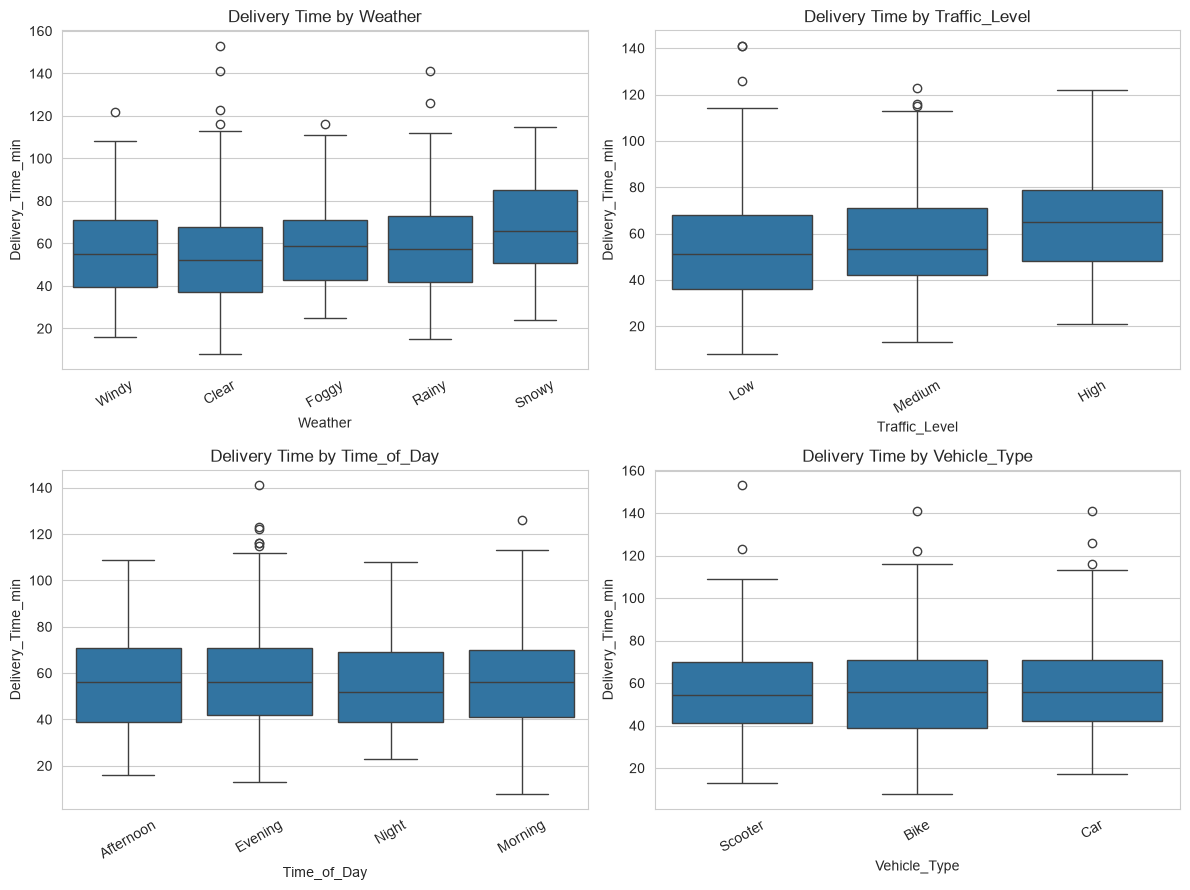

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y='Delivery_Time_min', ax=ax)
    ax.set_title(f'Delivery Time by {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Notes

- 1000 rows, 9 columns, target is `Delivery_Time_min`.
- Missing values in `Weather`, `Traffic_Level`, `Time_of_Day` and `Courier_Experience_yrs` (~30 rows each, ~3%).
- `Distance_km` has the strongest correlation with delivery time, `Preparation_Time_min` also matters.
- Traffic level and weather both push delivery time up, makes sense.
- `Order_ID` is just an identifier, won't be useful for modeling.
- Next step: cleaning the missing values.